# AdaBoost Scaling Experiment

**Experiment 2**: Vary n_estimators from 1 to 200 and observe performance

**Datasets**: Breast Cancer, Adult Income, Covertype, MNIST (Full - 10 classes)

## Configuration
Set experiment parameters here

In [39]:
# ============================================
# EXPERIMENT CONFIGURATION
# ============================================
CONFIG = {
    'max_estimators': 20,
    'step': 10,
    'test_size': 0.2,
    'random_state': 42,
    'sklearn_n_estimators': 20,
    'staged_n_estimators': 10,
}

# Extract values for easy access
MAX_ESTIMATORS = CONFIG['max_estimators']
STEP = CONFIG['step']
TEST_SIZE = CONFIG['test_size']
RANDOM_STATE = CONFIG['random_state']
SKLEARN_N_ESTIMATORS = CONFIG['sklearn_n_estimators']
STAGED_N_ESTIMATORS = CONFIG['staged_n_estimators']

print("\n" + "="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print("="*60)


EXPERIMENT CONFIGURATION
  max_estimators: 20
  step: 10
  test_size: 0.2
  random_state: 42
  sklearn_n_estimators: 20
  staged_n_estimators: 10


## 1. Imports and Setup

In [40]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append('..')

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data
)
from src.trees.boosting.adaboost import AdaBoostClassifier
from src.metrics.evaluation import accuracy_calculation, f1_score

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Imports successful!")

Imports successful!


## 2. Load Datasets

In [41]:
for x in ('X_bc', 'X_adult', 'X_cover', 'X_mnist'):
    print(f'{x} : {x in globals().keys()}')

X_bc : True
X_adult : True
X_cover : True
X_mnist : True


In [42]:
# %% [markdown]
# ## 2. Load Datasets

# %%
# Helper function to get memory usage
def get_memory_usage(obj):
    """Get memory usage of pandas or numpy object in MB."""
    if hasattr(obj, 'memory_usage'):
        # pandas DataFrame: memory_usage() returns Series, need sum()
        # pandas Series: memory_usage() returns int, no sum() needed
        mem = obj.memory_usage(deep=True)
        if hasattr(mem, 'sum'):
            return mem.sum() / 1024**2
        else:
            return mem / 1024**2
    elif hasattr(obj, 'nbytes'):
        # numpy array
        return obj.nbytes / 1024**2
    else:
        return 0

# Store memory stats
memory_stats = []

# Load Breast Cancer
if 'X_bc' not in globals().keys():
    X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=True, verbose=False)
    memory_stats.append({
        'Dataset': 'Breast_Cancer',
        'X_memory_mb': get_memory_usage(X_bc),
        'y_memory_mb': get_memory_usage(y_bc),
        'X_type': type(X_bc).__name__,
        'X_dtype': X_bc.dtypes if hasattr(X_bc, 'dtypes') else X_bc.dtype
    })

# Load Adult Income
if 'X_adult' not in globals().keys():
    X_adult, y_adult, _ = load_adult_income_data(drop_categorical=True, optimize_memory=True, verbose=False)

    # Process Adult Income (binary)
    # y_adult is a Series with values like '<=50K' and '>50K'
    y_adult_binary = (y_adult.str.replace('.', '', regex=False) == '>50K').astype(int)

    memory_stats.append({
        'Dataset': 'Adult_Income',
        'X_memory_mb': get_memory_usage(X_adult),
        'y_memory_mb': get_memory_usage(y_adult_binary),
        'X_type': type(X_adult).__name__,
        'X_dtype': X_adult.dtypes if hasattr(X_adult, 'dtypes') else X_adult.dtype
    })

# Load Covertype
if 'X_cover' not in globals().keys():
    X_cover, y_cover, _ = load_covertype_data(drop_categorical=True, optimize_memory=True, verbose=False)
    # Subsampling for testing - REMOVE for full experiment
    X_cover, y_cover = X_cover.sample(10_000), y_cover.sample(10_000)
    memory_stats.append({
        'Dataset': 'Covertype',
        'X_memory_mb': get_memory_usage(X_cover),
        'y_memory_mb': get_memory_usage(y_cover),
        'X_type': type(X_cover).__name__,
        'X_dtype': X_cover.dtypes if hasattr(X_cover, 'dtypes') else X_cover.dtype
    })

# Load MNIST with downcasting (pandas)
if 'X_mnist' not in globals().keys():
    X_mnist, y_mnist, _ = load_mnist_data(
        optimize_memory=True,
        verbose=False,
        return_numpy=False  # Returns pandas with downcasted dtypes
    )
    # Subsampling for testing - REMOVE for full experiment
    X_mnist, y_mnist = X_mnist.sample(500), y_mnist.sample(500)
    memory_stats.append({
        'Dataset': 'MNIST',
        'X_memory_mb': get_memory_usage(X_mnist),
        'y_memory_mb': get_memory_usage(y_mnist),
        'X_type': type(X_mnist).__name__,
        'X_dtype': X_mnist.dtypes if hasattr(X_mnist, 'dtypes') else X_mnist.dtype
    })

# Process Covertype (keep all 7 classes)
y_cover_flat = y_cover.values.ravel()

# Create datasets dictionary
datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover.values, y_cover_flat),
    "MNIST": (X_mnist, y_mnist)  # Pandas DataFrame/Series - works with scikit-learn
}

print("\n" + "="*60)
print("DATASETS LOADED")
print("="*60)

total_memory = 0
for name, (X, y) in datasets.items():
    # Get memory
    if hasattr(X, 'memory_usage'):
        mem = X.memory_usage(deep=True)
        x_mem = mem.sum() / 1024**2 if hasattr(mem, 'sum') else mem / 1024**2
    else:
        x_mem = X.nbytes / 1024**2

    if hasattr(y, 'memory_usage'):
        mem = y.memory_usage(deep=True)
        y_mem = mem.sum() / 1024**2 if hasattr(mem, 'sum') else mem / 1024**2
    else:
        y_mem = y.nbytes / 1024**2

    total_memory += x_mem + y_mem

    print(f"\n{name}:")
    print(f"  Shape: {X.shape}")
    print(f"  Classes: {np.unique(y)}")
    print(f"  X type: {type(X).__name__}")

    if hasattr(X, 'dtypes'):
        print(f"  X dtypes: {X.dtypes.value_counts().to_dict()}")
    else:
        print(f"  X dtype: {X.dtype}")

    print(f"  y dtype: {y.dtype}")
    print(f"  X memory: {x_mem:.1f} MB")
    print(f"  y memory: {y_mem:.1f} MB")
    print(f"  Total memory: {x_mem + y_mem:.1f} MB")

print(f"\n{'='*60}")
print(f"TOTAL MEMORY FOR ALL DATASETS: {total_memory:.1f} MB")
print("="*60)

# Show memory comparison table
print("\nMEMORY COMPARISON TABLE:")
print("-" * 80)
print(f"{'Dataset':<20} {'X Memory (MB)':<15} {'y Memory (MB)':<15} {'X Type':<15} {'X Dtype'}")
print("-" * 80)
for stat in memory_stats:
    print(f"{stat['Dataset']:<20} {stat['X_memory_mb']:<15.1f} {stat['y_memory_mb']:<15.1f} {stat['X_type']:<15} {str(stat['X_dtype'])[:30]}")
print("-" * 80)


DATASETS LOADED

Breast_Cancer:
  Shape: (569, 30)
  Classes: [0 1]
  X type: ndarray
  X dtype: float64
  y dtype: int8
  X memory: 0.1 MB
  y memory: 0.0 MB
  Total memory: 0.1 MB

Adult_Income:
  Shape: (48842, 6)
  Classes: [0 1]
  X type: ndarray
  X dtype: int64
  y dtype: int64
  X memory: 2.2 MB
  y memory: 0.4 MB
  Total memory: 2.6 MB

Covertype:
  Shape: (10000, 10)
  Classes: [1 2 3 4 5 6 7]
  X type: ndarray
  X dtype: int64
  y dtype: int8
  X memory: 0.8 MB
  y memory: 0.0 MB
  Total memory: 0.8 MB

MNIST:
  Shape: (500, 784)
  Classes: [0 1 2 3 4 5 6 7 8 9]
  X type: DataFrame
  X dtypes: {dtype('int64'): 784}
  y dtype: int8
  X memory: 3.0 MB
  y memory: 0.0 MB
  Total memory: 3.0 MB

TOTAL MEMORY FOR ALL DATASETS: 6.5 MB

MEMORY COMPARISON TABLE:
--------------------------------------------------------------------------------
Dataset              X Memory (MB)   y Memory (MB)   X Type          X Dtype
-----------------------------------------------------------------

## 3. Define Experiment Functions (Sequential)

In [43]:
def run_adaboost_scaling(X, y, dataset_name, max_estimators=None, step=None):
    """
    Run AdaBoost scaling experiment for a single dataset.

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target labels
    dataset_name : str
        Name of dataset for logging
    max_estimators : int, optional
        Maximum number of estimators to test. Uses CONFIG if None.
    step : int, optional
        Step size for varying n_estimators. Uses CONFIG if None.

    Returns:
    --------
    dict: Results containing train/test metrics for each n_estimators
    """

    # Use config values if not provided
    if max_estimators is None:
        max_estimators = MAX_ESTIMATORS
    if step is None:
        step = STEP

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    n_estimators_list = list(range(1, max_estimators + 1, step))

    train_acc = []
    test_acc = []
    train_f1 = []
    test_f1 = []

    if len(np.unique(y)) == 2:
        f1_mean = 'binary'
    else:
        f1_mean = 'macro'

    for n_est in n_estimators_list:
        model = AdaBoostClassifier(
            n_estimators=n_est,
            learning_rate=1.0,
            criterion="gini",
            random_state=RANDOM_STATE
        )
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_acc.append(accuracy_calculation(y_train, train_pred))
        test_acc.append(accuracy_calculation(y_test, test_pred))
        train_f1.append(f1_score(y_train, train_pred, mean=f1_mean))
        test_f1.append(f1_score(y_test, test_pred, mean=f1_mean))

    return {
        "dataset": dataset_name,
        "n_estimators": n_estimators_list,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1
    }

def train_dataset_sequential(name, X, y, max_estimators=None, step=None):
    """
    Train a single dataset sequentially.

    Parameters:
    -----------
    name : str
        Dataset name
    X, y : np.ndarray
        Features and labels
    max_estimators, step : int, optional
        Experiment parameters. Uses CONFIG if None.

    Returns:
    --------
    tuple: (dataset_name, results_dict)
    """
    if max_estimators is None:
        max_estimators = MAX_ESTIMATORS
    if step is None:
        step = STEP

    print(f"[{time.strftime('%H:%M:%S')}] Starting {name}...")
    print(f"  Training {len(range(1, max_estimators + 1, step))} models...")
    start = time.perf_counter()
    result = run_adaboost_scaling(X, y, name, max_estimators, step)
    elapsed = time.perf_counter() - start
    print(f"[{time.strftime('%H:%M:%S')}] Finished {name}! ({elapsed:.2f}s)")
    return name, result

def run_all_sequential(datasets, max_estimators=None, step=None):
    """
    Run AdaBoost scaling experiments on all datasets sequentially.

    Parameters:
    -----------
    datasets : dict
        Dictionary mapping dataset names to (X, y) tuples
    max_estimators, step : int, optional
        Experiment parameters. Uses CONFIG if None.

    Returns:
    --------
    dict: Results for all datasets
    """
    if max_estimators is None:
        max_estimators = MAX_ESTIMATORS
    if step is None:
        step = STEP

    print(f"\nStarting sequential execution...")
    print(f"Testing n_estimators from 1 to {max_estimators} (step {step})")
    print("="*60)
    start = time.perf_counter()

    results = {}
    for name, (X, y) in datasets.items():
        name, result = train_dataset_sequential(name, X, y, max_estimators, step)
        results[name] = result

    total = time.perf_counter() - start
    print("="*60)
    print(f"All datasets complete! Total time: {total:.2f}s ({total/60:.2f} minutes)")

    return results, total

In [44]:
# it is commented out for experimentation. after experiment, it needs to be commented out.
# Run experiments sequentially
print("Running AdaBoost scaling experiment (sequential)...")
results, TOTAL_TIME = run_all_sequential(datasets)

Running AdaBoost scaling experiment (sequential)...

Starting sequential execution...
Testing n_estimators from 1 to 20 (step 10)
[15:59:33] Starting Breast_Cancer...
  Training 2 models...
[15:59:35] Finished Breast_Cancer! (1.86s)
[15:59:35] Starting Adult_Income...
  Training 2 models...
[15:59:44] Finished Adult_Income! (8.48s)
[15:59:44] Starting Covertype...
  Training 2 models...
[15:59:46] Finished Covertype! (2.34s)
[15:59:46] Starting MNIST...
  Training 2 models...
[15:59:53] Finished MNIST! (7.24s)
All datasets complete! Total time: 19.92s (0.33 minutes)


## 4. Plot Results

In [45]:
def plot_adaboost_scaling(results, save_path=None):
    """
    Plot accuracy and F1 vs number of estimators.

    Parameters:
    -----------
    results : dict
        Results dictionary from run_adaboost_scaling()
    save_path : str, optional
        Path to save the figure
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(results["n_estimators"], results["train_acc"],
                label="Training", marker='o', markersize=4, linewidth=2)
    axes[0].plot(results["n_estimators"], results["test_acc"],
                label="Test", marker='s', markersize=4, linewidth=2)
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[0].set_xlabel("Number of Estimators")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{results['dataset']} - Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(results["n_estimators"], results["train_f1"],
                label="Training", marker='o', markersize=4, linewidth=2)
    axes[1].plot(results["n_estimators"], results["test_f1"],
                label="Test", marker='s', markersize=4, linewidth=2)
    axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[1].set_xlabel("Number of Estimators")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title(f"{results['dataset']} - F1 Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Figure saved: {save_path}")

    plt.show()


GENERATING PLOTS

Plotting Breast_Cancer...
  Figure saved: ../figures/adaboost_scaling_Breast_Cancer.png


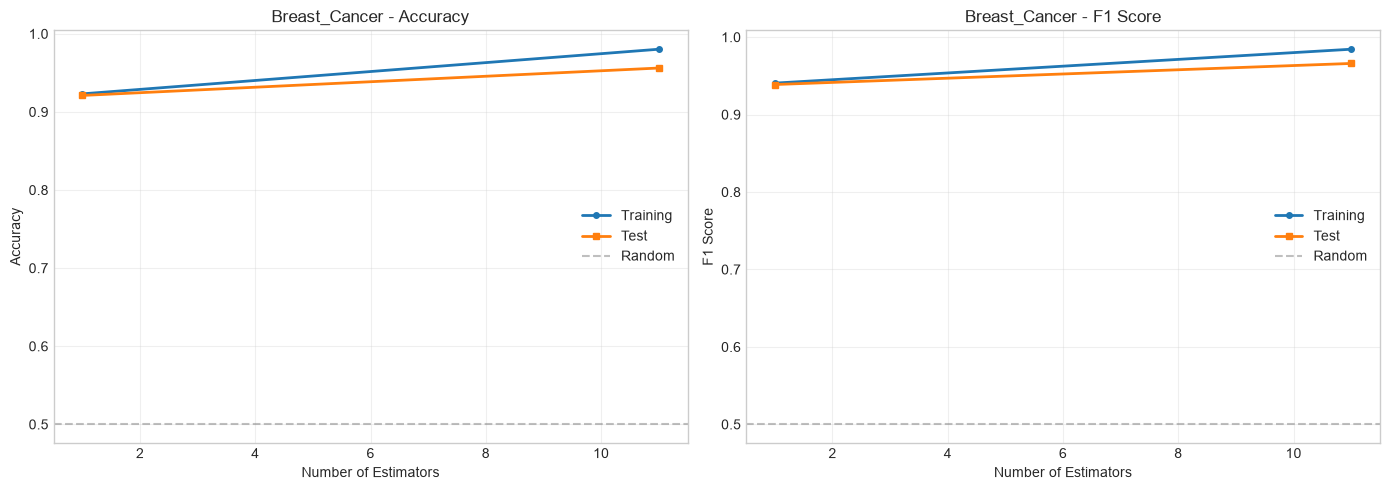


Plotting Adult_Income...
  Figure saved: ../figures/adaboost_scaling_Adult_Income.png


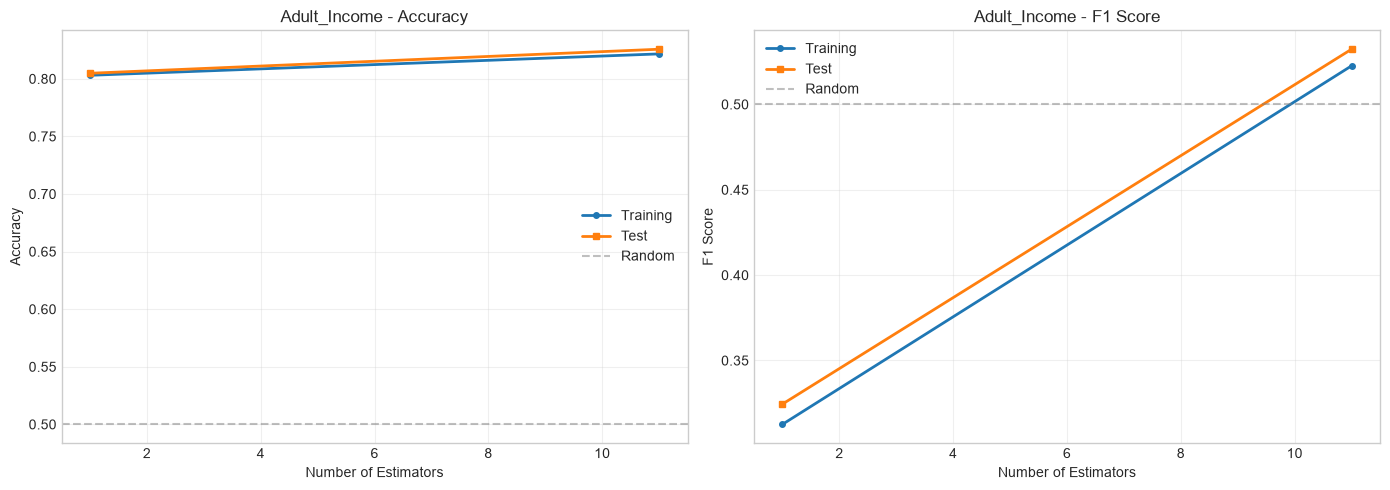


Plotting Covertype...
  Figure saved: ../figures/adaboost_scaling_Covertype.png


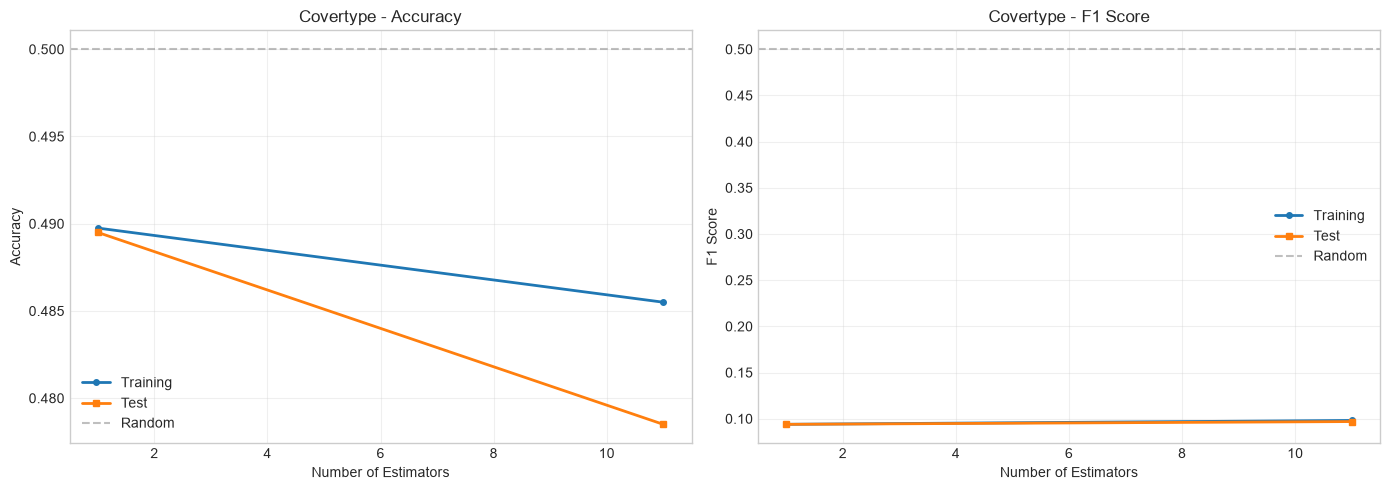


Plotting MNIST...
  Figure saved: ../figures/adaboost_scaling_MNIST.png


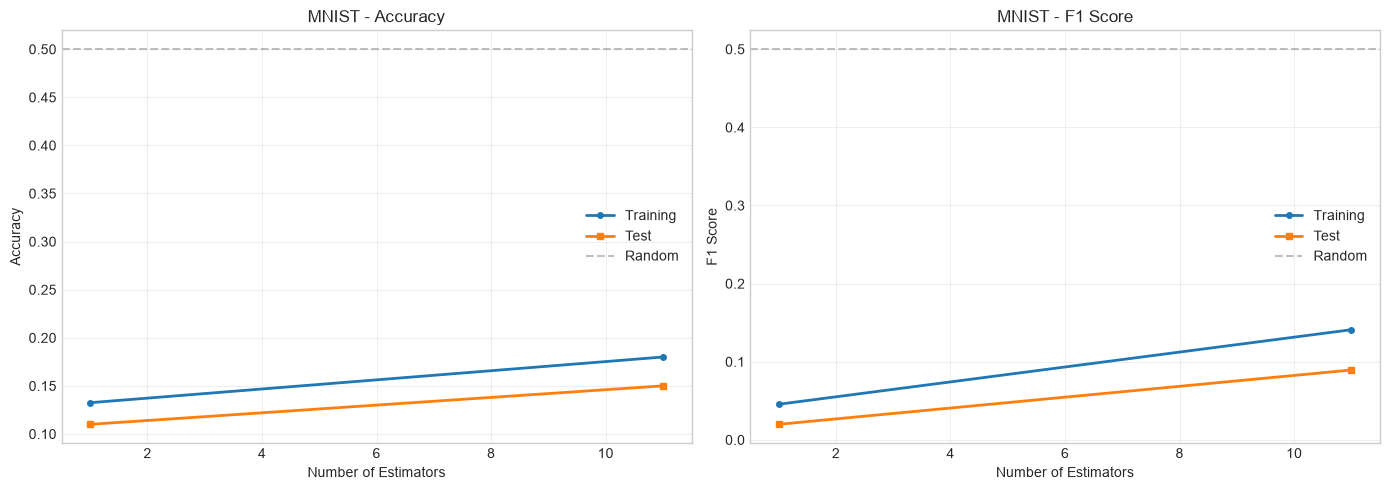

In [46]:
# Plot all datasets
print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)

for name, result in results.items():
    print(f"\nPlotting {name}...")
    plot_adaboost_scaling(result, save_path=f"../figures/adaboost_scaling_{name}.png")

## 5. Summary Table

In [47]:
# Generate summary of best results
summary = []

for name, result in results.items():
    best_idx = np.argmax(result["test_acc"])
    summary.append({
        "Dataset": name,
        "Best n_estimators": result["n_estimators"][best_idx],
        "Best Test Accuracy": result["test_acc"][best_idx],
        "Best Test F1": result["test_f1"][best_idx],
        "Final Test Accuracy": result["test_acc"][-1],
        "Train-Test Gap": result["train_acc"][-1] - result["test_acc"][-1]
    })

summary_df = pd.DataFrame(summary)

print("\n" + "="*60)
print("ADA BOOST SCALING RESULTS SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)

best_overall_idx = np.argmax(summary_df["Best Test Accuracy"])
print(f"\nBest overall performance: {summary_df.iloc[best_overall_idx]['Dataset']}")
print(f"   Accuracy: {summary_df.iloc[best_overall_idx]['Best Test Accuracy']:.4f}")
print(f"   n_estimators: {summary_df.iloc[best_overall_idx]['Best n_estimators']}")


ADA BOOST SCALING RESULTS SUMMARY
      Dataset  Best n_estimators  Best Test Accuracy  Best Test F1  Final Test Accuracy  Train-Test Gap
Breast_Cancer                 11            0.956140      0.965986             0.956140        0.024079
 Adult_Income                 11            0.825673      0.532271             0.825673       -0.004057
    Covertype                  1            0.489500      0.093895             0.478500        0.007000
        MNIST                 11            0.150000      0.089368             0.150000        0.030000

Best overall performance: Breast_Cancer
   Accuracy: 0.9561
   n_estimators: 11


## 6. Overfitting Analysis

In [48]:
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

for name, result in results.items():
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    print(f"\n{name}:")
    print(f"  Best test accuracy: {max(test_acc):.4f} at n={result['n_estimators'][np.argmax(test_acc)]}")
    print(f"  Final test accuracy: {test_acc[-1]:.4f}")
    print(f"  Max overfitting gap: {max(gap):.4f}")
    print(f"  Final overfitting gap: {gap[-1]:.4f}")

    if max(gap) > 0.05:
        print("  WARNING: Significant overfitting detected (>5%)")
    elif max(gap) > 0.02:
        print("  Some overfitting detected (2-5%)")
    else:
        print("  No significant overfitting (<2%)")


OVERFITTING ANALYSIS

Breast_Cancer:
  Best test accuracy: 0.9561 at n=11
  Final test accuracy: 0.9561
  Max overfitting gap: 0.0241
  Final overfitting gap: 0.0241
  Some overfitting detected (2-5%)

Adult_Income:
  Best test accuracy: 0.8257 at n=11
  Final test accuracy: 0.8257
  Max overfitting gap: -0.0018
  Final overfitting gap: -0.0041
  No significant overfitting (<2%)

Covertype:
  Best test accuracy: 0.4895 at n=1
  Final test accuracy: 0.4785
  Max overfitting gap: 0.0070
  Final overfitting gap: 0.0070
  No significant overfitting (<2%)

MNIST:
  Best test accuracy: 0.1500 at n=11
  Final test accuracy: 0.1500
  Max overfitting gap: 0.0300
  Final overfitting gap: 0.0300
  Some overfitting detected (2-5%)


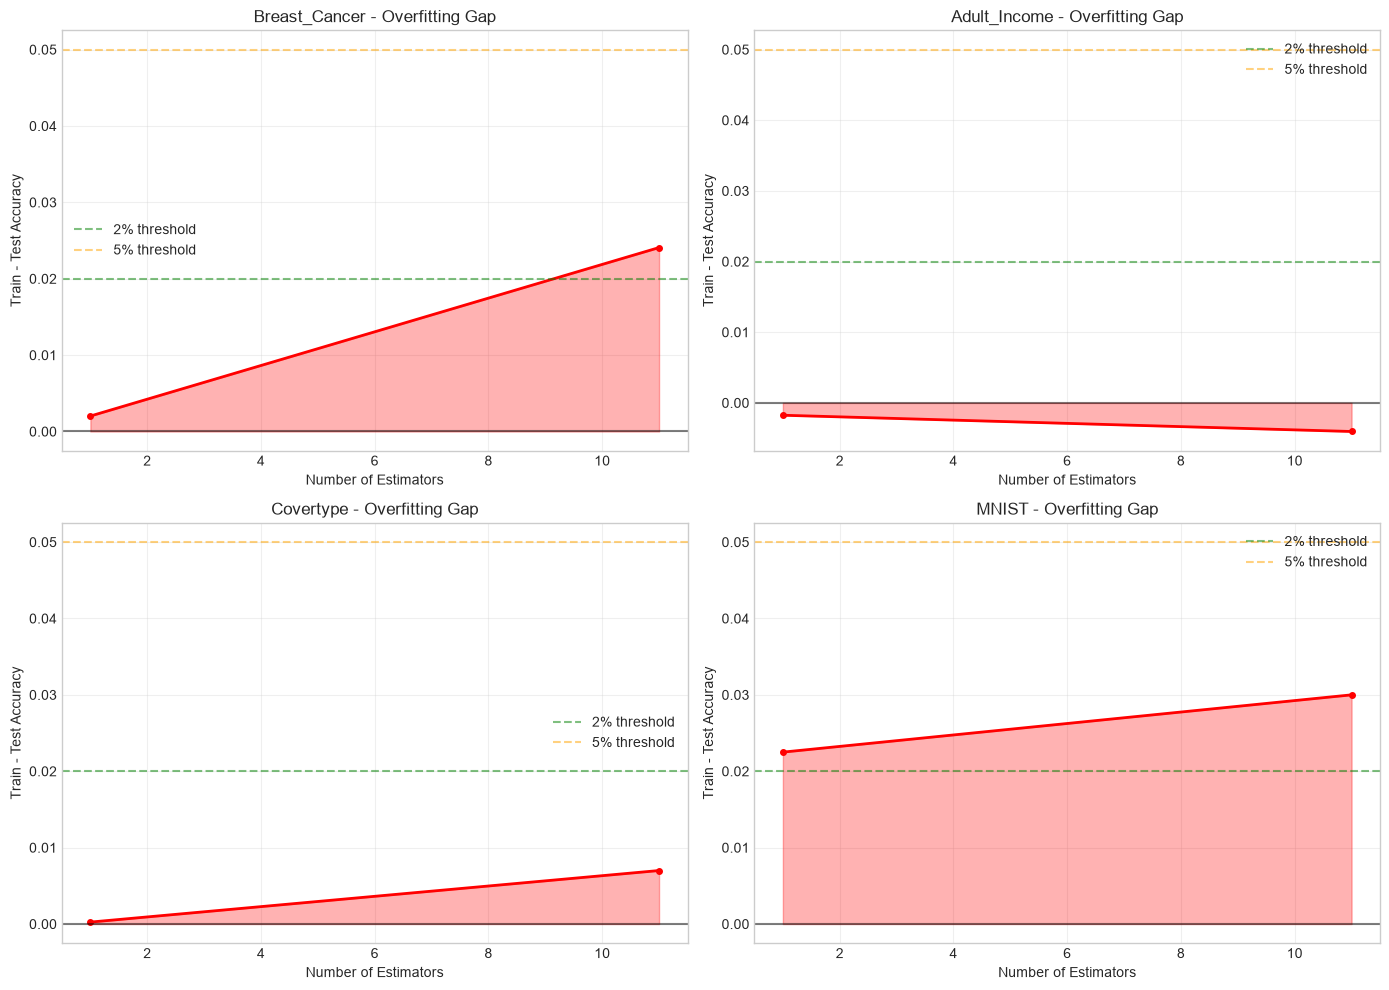


Overfitting analysis figure saved: figures/overfitting_analysis.png


In [49]:
# Visualize overfitting gaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    ax = axes[idx]
    ax.plot(result["n_estimators"], gap, color='red', linewidth=2, marker='o', markersize=4)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.axhline(y=0.02, color='green', linestyle='--', alpha=0.5, label='2% threshold')
    ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, label='5% threshold')
    ax.fill_between(result["n_estimators"], 0, gap, alpha=0.3, color='red')
    ax.set_xlabel("Number of Estimators")
    ax.set_ylabel("Train - Test Accuracy")
    ax.set_title(f"{name} - Overfitting Gap")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/overfitting_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("\nOverfitting analysis figure saved: figures/overfitting_analysis.png")

## 7. Staged Predictions Analysis

Using `staged_predict()` to analyze performance at each boosting round.

In [50]:
def analyze_staged_predictions(X, y, dataset_name, n_estimators=None):
    """
    Use staged_predict to analyze performance at each boosting round.

    Parameters:
    -----------
    X, y : np.ndarray
        Features and labels
    dataset_name : str
        Name of dataset for plotting
    n_estimators : int, optional
        Number of estimators to train. Uses CONFIG if None.
    """

    if n_estimators is None:
        n_estimators = STAGED_N_ESTIMATORS

    print(f"  Analyzing staged predictions for {dataset_name}...")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=1.0,
        criterion="gini",
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)

    staged_train_acc = []
    staged_test_acc = []

    for pred_train in model.staged_predict(X_train_scaled):
        staged_train_acc.append(accuracy_calculation(y_train, pred_train))

    for pred_test in model.staged_predict(X_test_scaled):
        staged_test_acc.append(accuracy_calculation(y_test, pred_test))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    stages = range(1, len(staged_train_acc) + 1)

    axes[0].plot(stages, staged_train_acc, label='Training', linewidth=2)
    axes[0].plot(stages, staged_test_acc, label='Test', linewidth=2)
    axes[0].set_xlabel("Boosting Round")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{dataset_name} - Staged Performance")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    gap = np.array(staged_train_acc) - np.array(staged_test_acc)
    axes[1].plot(stages, gap, color='red', linewidth=2)
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[1].set_xlabel("Boosting Round")
    axes[1].set_ylabel("Train - Test Accuracy")
    axes[1].set_title(f"{dataset_name} - Overfitting Gap Over Rounds")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"../figures/staged_predictions_{dataset_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"    Final training accuracy: {staged_train_acc[-1]:.4f}")
    print(f"    Final test accuracy: {staged_test_acc[-1]:.4f}")
    print(f"    Final gap: {gap[-1]:.4f}")


STAGED PREDICTIONS ANALYSIS
  Analyzing staged predictions for Breast_Cancer...


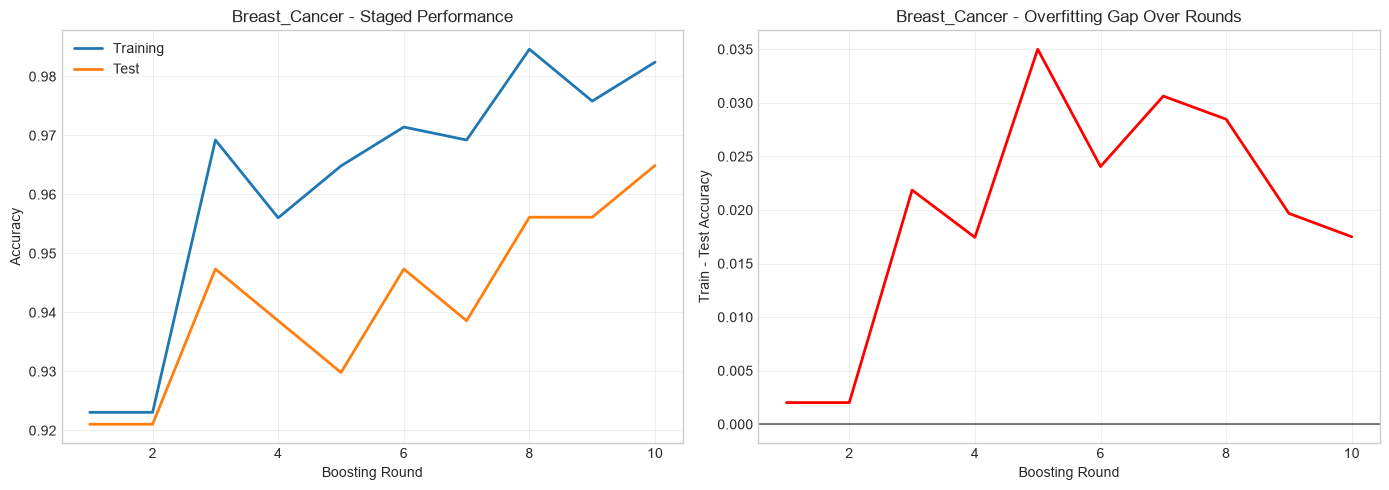

    Final training accuracy: 0.9824
    Final test accuracy: 0.9649
    Final gap: 0.0175
  Analyzing staged predictions for Adult_Income...


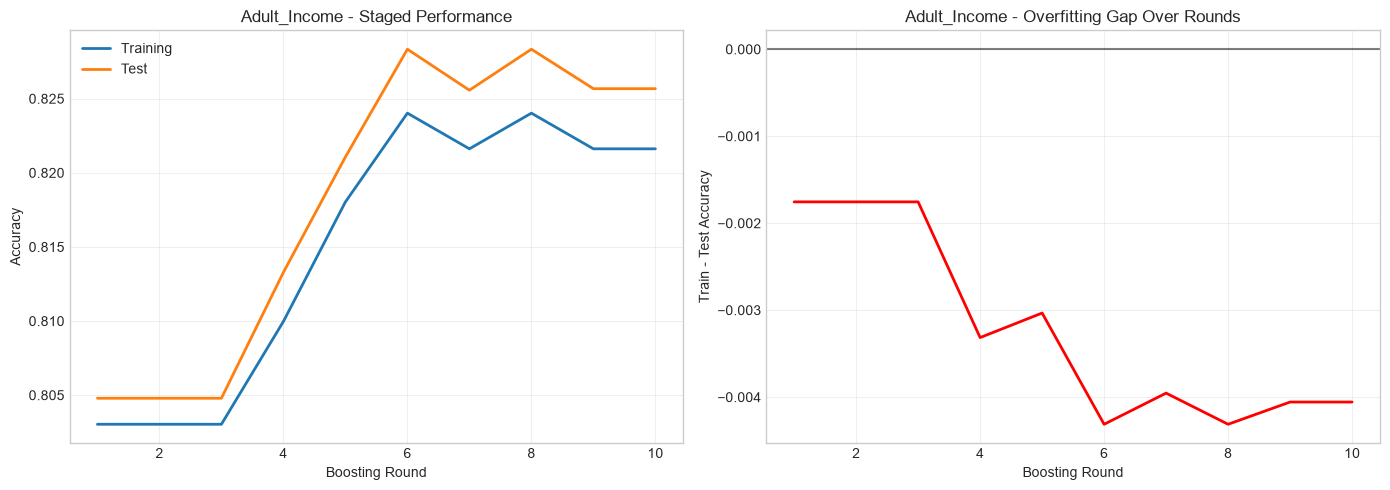

    Final training accuracy: 0.8216
    Final test accuracy: 0.8257
    Final gap: -0.0041
  Analyzing staged predictions for Covertype...


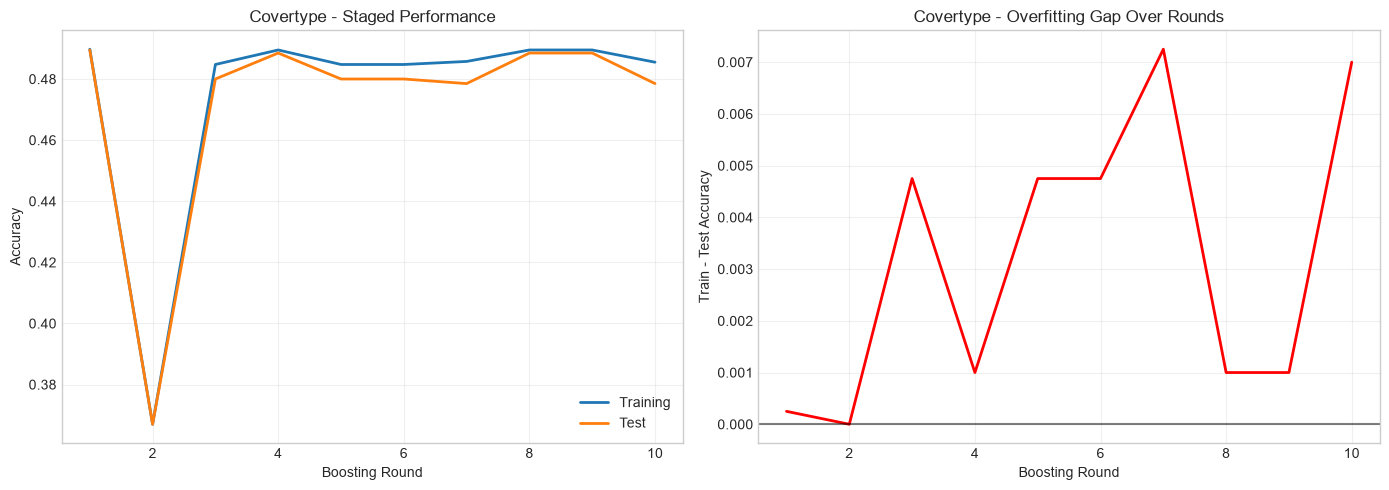

    Final training accuracy: 0.4855
    Final test accuracy: 0.4785
    Final gap: 0.0070
  Analyzing staged predictions for MNIST...


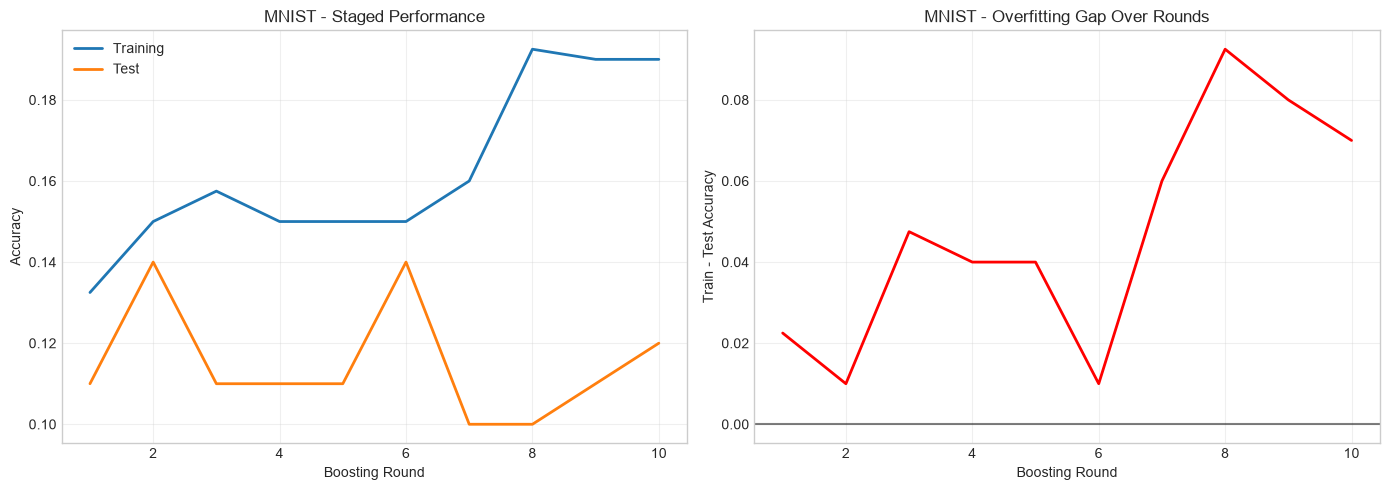

    Final training accuracy: 0.1900
    Final test accuracy: 0.1200
    Final gap: 0.0700


In [51]:
# Analyze staged predictions for each dataset
print("\n" + "="*60)
print("STAGED PREDICTIONS ANALYSIS")
print("="*60)

for name, (X, y) in datasets.items():
    analyze_staged_predictions(X, y, name)

## 8. sklearn Comparison (Sanity Check)

Compare our AdaBoost implementation with sklearn's implementation.
Required by project: must be within 2% tolerance.

In [52]:
from sklearn.ensemble import AdaBoostClassifier as SklearnAdaBoost
from sklearn.tree import DecisionTreeClassifier as SklearnDT

def compare_with_sklearn(X, y, dataset_name, n_estimators=None):
    """
    Compare our AdaBoost with sklearn's implementation.

    Parameters:
    -----------
    X, y : np.ndarray
        Features and labels
    dataset_name : str
        Name of dataset for logging
    n_estimators : int, optional
        Number of estimators to use for comparison. Uses CONFIG if None.

    Returns:
    --------
    tuple: (our_accuracy, sklearn_accuracy)
    """

    if n_estimators is None:
        n_estimators = SKLEARN_N_ESTIMATORS

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    our_model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=1.0,
        criterion="gini",
        random_state=RANDOM_STATE
    )
    our_model.fit(X_train_scaled, y_train)
    our_acc = accuracy_calculation(y_test, our_model.predict(X_test_scaled))

    sk_model = SklearnAdaBoost(
        estimator=SklearnDT(max_depth=1),
        n_estimators=n_estimators,
        learning_rate=1.0,
        random_state=RANDOM_STATE
    )
    sk_model.fit(X_train_scaled, y_train)
    sk_acc = accuracy_calculation(y_test, sk_model.predict(X_test_scaled))

    diff = abs(our_acc - sk_acc)

    print(f"  Our:      {our_acc:.4f}")
    print(f"  sklearn:  {sk_acc:.4f}")
    print(f"  Diff:     {diff:.4f}")

    if diff < 0.02:
        print(f"  OK: Within 2% tolerance")
    else:
        print(f"  WARNING: Difference > 2%")

    return our_acc, sk_acc

In [53]:
# Compare with sklearn for each dataset
print("\n" + "="*60)
print("SKLEARN COMPARISON")
print("="*60)

comparison_results = []

for name, (X, y) in datasets.items():
    print(f"\n{name}:")
    our_acc, sk_acc = compare_with_sklearn(X, y, name)
    comparison_results.append({
        "Dataset": name,
        "Our Accuracy": our_acc,
        "sklearn Accuracy": sk_acc,
        "Difference": abs(our_acc - sk_acc),
        "Pass": abs(our_acc - sk_acc) < 0.02
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))

all_passed = all(comparison_df["Pass"])
if all_passed:
    print("\nAll datasets passed the 2% tolerance check!")
else:
    print("\nSome datasets failed the 2% tolerance check!")


SKLEARN COMPARISON

Breast_Cancer:
  Our:      0.9561
  sklearn:  0.9561
  Diff:     0.0000
  OK: Within 2% tolerance

Adult_Income:
  Our:      0.8303
  sklearn:  0.8303
  Diff:     0.0000
  OK: Within 2% tolerance

Covertype:
  Our:      0.4885
  sklearn:  0.4885
  Diff:     0.0000
  OK: Within 2% tolerance

MNIST:
  Our:      0.1300
  sklearn:  0.1200
  Diff:     0.0100
  OK: Within 2% tolerance

COMPARISON SUMMARY
      Dataset  Our Accuracy  sklearn Accuracy  Difference  Pass
Breast_Cancer      0.956140          0.956140        0.00  True
 Adult_Income      0.830279          0.830279        0.00  True
    Covertype      0.488500          0.488500        0.00  True
        MNIST      0.130000          0.120000        0.01  True

All datasets passed the 2% tolerance check!


## 9. Save All Results

Save results in CSV format for report and future reference.

In [54]:
import os

os.makedirs("../notebooks", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

summary_df = pd.DataFrame(summary)
summary_df.to_csv("../notebooks/adaboost_scaling_summary.csv", index=False)
print("Summary saved: notebooks/adaboost_scaling_summary.csv")

for name, result in results.items():
    df = pd.DataFrame({
        'n_estimators': result['n_estimators'],
        'train_acc': result['train_acc'],
        'test_acc': result['test_acc'],
        'train_f1': result['train_f1'],
        'test_f1': result['test_f1']
    })
    filename = f"../notebooks/adaboost_scaling_{name}_details.csv"
    df.to_csv(filename, index=False)
    print(f"Detailed results saved: notebooks/adaboost_scaling_{name}_details.csv")

best_results = []
for name, result in results.items():
    best_idx = np.argmax(result["test_acc"])
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])

    best_results.append({
        "Dataset": name,
        "Best n_estimators": result["n_estimators"][best_idx],
        "Best Test Accuracy": result["test_acc"][best_idx],
        "Best Test F1": result["test_f1"][best_idx],
        "Final Test Accuracy": result["test_acc"][-1],
        "Train-Test Gap": result["train_acc"][-1] - result["test_acc"][-1],
        "Max Overfitting Gap": max(train_acc - test_acc),
        "Number of Classes": len(np.unique(datasets[name][1]))
    })

best_df = pd.DataFrame(best_results)
best_df.to_csv("../notebooks/adaboost_scaling_best_results.csv", index=False)
print("Best results saved: notebooks/adaboost_scaling_best_results.csv")

comparison_df.to_csv("../notebooks/adaboost_scaling_sklearn_comparison.csv", index=False)
print("sklearn comparison saved: notebooks/adaboost_scaling_sklearn_comparison.csv")

metadata = {
    "experiment": "AdaBoost Scaling",
    "date": time.strftime("%Y-%m-%d %H:%M:%S"),
    "max_estimators": MAX_ESTIMATORS,
    "step": STEP,
    "datasets": list(datasets.keys()),
    "total_time_seconds": TOTAL_TIME,
    "results_summary": summary_df.to_dict(orient='records')
}

with open('../notebooks/experiment_metadata.csv', 'w') as f:
    import csv
    writer = csv.writer(f)
    writer.writerow(['key', 'value'])
    for key, value in metadata.items():
        if key != 'results_summary':
            writer.writerow([key, value])

print("Metadata saved: notebooks/experiment_metadata.csv")

print("\n" + "="*60)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("="*60)


SAVING RESULTS
Summary saved: notebooks/adaboost_scaling_summary.csv
Detailed results saved: notebooks/adaboost_scaling_Breast_Cancer_details.csv
Detailed results saved: notebooks/adaboost_scaling_Adult_Income_details.csv
Detailed results saved: notebooks/adaboost_scaling_Covertype_details.csv
Detailed results saved: notebooks/adaboost_scaling_MNIST_details.csv
Best results saved: notebooks/adaboost_scaling_best_results.csv
sklearn comparison saved: notebooks/adaboost_scaling_sklearn_comparison.csv
Metadata saved: notebooks/experiment_metadata.csv

ALL RESULTS SAVED SUCCESSFULLY


## 10. Final Summary Report

In [55]:
print("\n" + "="*80)
print(" " * 25 + "ADA BOOST SCALING EXPERIMENT")
print(" " * 20 + "FINAL SUMMARY REPORT")
print("="*80)

print("\nEXPERIMENT OVERVIEW")
print("-" * 40)
print(f"  Date: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Datasets tested: {len(datasets)}")
print(f"  n_estimators range: 1 to {MAX_ESTIMATORS} (step {STEP})")
print(f"  Total configurations: {len(range(1, MAX_ESTIMATORS + 1, STEP))} per dataset")
print(f"  Total time: {TOTAL_TIME:.2f}s ({TOTAL_TIME/60:.2f} minutes)")

print("\nDATASETS SUMMARY")
print("-" * 40)
for name, (X, y) in datasets.items():
    print(f"  {name}:")
    print(f"    Samples: {X.shape[0]:,}")
    print(f"    Features: {X.shape[1]}")
    print(f"    Classes: {len(np.unique(y))}")
    if len(np.unique(y)) <= 10:
        print(f"    Class distribution: {np.bincount(y.astype(int))}")


                         ADA BOOST SCALING EXPERIMENT
                    FINAL SUMMARY REPORT

EXPERIMENT OVERVIEW
----------------------------------------
  Date: 2026-07-11 16:00:49
  Datasets tested: 4
  n_estimators range: 1 to 20 (step 10)
  Total configurations: 2 per dataset
  Total time: 19.92s (0.33 minutes)

DATASETS SUMMARY
----------------------------------------
  Breast_Cancer:
    Samples: 569
    Features: 30
    Classes: 2
    Class distribution: [212 357]
  Adult_Income:
    Samples: 48,842
    Features: 6
    Classes: 2
    Class distribution: [37155 11687]
  Covertype:
    Samples: 10,000
    Features: 10
    Classes: 7
    Class distribution: [   0 3670 4897  597   39  153  300  344]
  MNIST:
    Samples: 500
    Features: 784
    Classes: 10
    Class distribution: [50 58 56 49 48 40 49 41 51 58]


In [56]:
print("\nBEST RESULTS PER DATASET")
print("-" * 40)
if 'best_df' in locals():
    print(best_df.to_string(index=False))
else:
    print("Error: best_df not defined. Please run Cell 9 first.")


BEST RESULTS PER DATASET
----------------------------------------
      Dataset  Best n_estimators  Best Test Accuracy  Best Test F1  Final Test Accuracy  Train-Test Gap  Max Overfitting Gap  Number of Classes
Breast_Cancer                 11            0.956140      0.965986             0.956140        0.024079             0.024079                  2
 Adult_Income                 11            0.825673      0.532271             0.825673       -0.004057            -0.001755                  2
    Covertype                  1            0.489500      0.093895             0.478500        0.007000             0.007000                  7
        MNIST                 11            0.150000      0.089368             0.150000        0.030000             0.030000                 10


In [57]:
print("\nKEY FINDINGS")
print("-" * 40)

if 'best_df' in locals():
    best_row = best_df.loc[best_df['Best Test Accuracy'].idxmax()]
    print(f"  Best Overall Accuracy: {best_row['Dataset']}")
    print(f"     Accuracy: {best_row['Best Test Accuracy']:.4f}")
    print(f"     n_estimators: {best_row['Best n_estimators']}")

    best_f1_row = best_df.loc[best_df['Best Test F1'].idxmax()]
    print(f"\n  Best Overall F1: {best_f1_row['Dataset']}")
    print(f"     F1: {best_f1_row['Best Test F1']:.4f}")
    print(f"     n_estimators: {best_f1_row['Best n_estimators']}")

    print("\n  Overfitting Analysis:")
    for _, row in best_df.iterrows():
        gap = row['Max Overfitting Gap']
        status = "Low" if gap < 0.02 else "Moderate" if gap < 0.05 else "High"
        print(f"    {row['Dataset']}: Max gap = {gap:.4f} ({status})")
else:
    print("  Run Cell 9 first to generate best_results.")

print("\n  sklearn Validation:")
for _, row in comparison_df.iterrows():
    status = "Pass" if row['Pass'] else "Fail"
    print(f"    {row['Dataset']}: Diff = {row['Difference']:.4f} ({status})")


KEY FINDINGS
----------------------------------------
  Best Overall Accuracy: Breast_Cancer
     Accuracy: 0.9561
     n_estimators: 11

  Best Overall F1: Breast_Cancer
     F1: 0.9660
     n_estimators: 11

  Overfitting Analysis:
    Breast_Cancer: Max gap = 0.0241 (Moderate)
    Adult_Income: Max gap = -0.0018 (Low)
    Covertype: Max gap = 0.0070 (Low)
    MNIST: Max gap = 0.0300 (Moderate)

  sklearn Validation:
    Breast_Cancer: Diff = 0.0000 (Pass)
    Adult_Income: Diff = 0.0000 (Pass)
    Covertype: Diff = 0.0000 (Pass)
    MNIST: Diff = 0.0100 (Pass)
